In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns       
import plotly.express as px
import numpy as np

In [73]:
from pandas import read_csv
df = pd.DataFrame(read_csv('Weather.csv'))
df.head(10)


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
5,1/1/2012 5:00,-1.4,-3.3,87,9,6.4,101.27,Fog
6,1/1/2012 6:00,-1.5,-3.1,89,7,6.4,101.29,Fog
7,1/1/2012 7:00,-1.4,-3.6,85,7,8.0,101.26,Fog
8,1/1/2012 8:00,-1.4,-3.6,85,9,8.0,101.23,Fog
9,1/1/2012 9:00,-1.3,-3.1,88,15,4.0,101.20,Fog


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [75]:
df.groupby('Weather')['Press_kPa'].count().sort_values(ascending=False)

Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Haze                                         16
Thunderstorms,Rain Showers                   16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle                

In [76]:
keep_categories = ['Mainly Clear', 'Mostly Cloudy', 'Clear', 'Cloudy', 'Snow', 'Rain', 'Fog']

# Create a new column with grouped categories
df['Weather_Grouped'] = df['Weather'].apply(lambda x: x if x in keep_categories else 'Others')

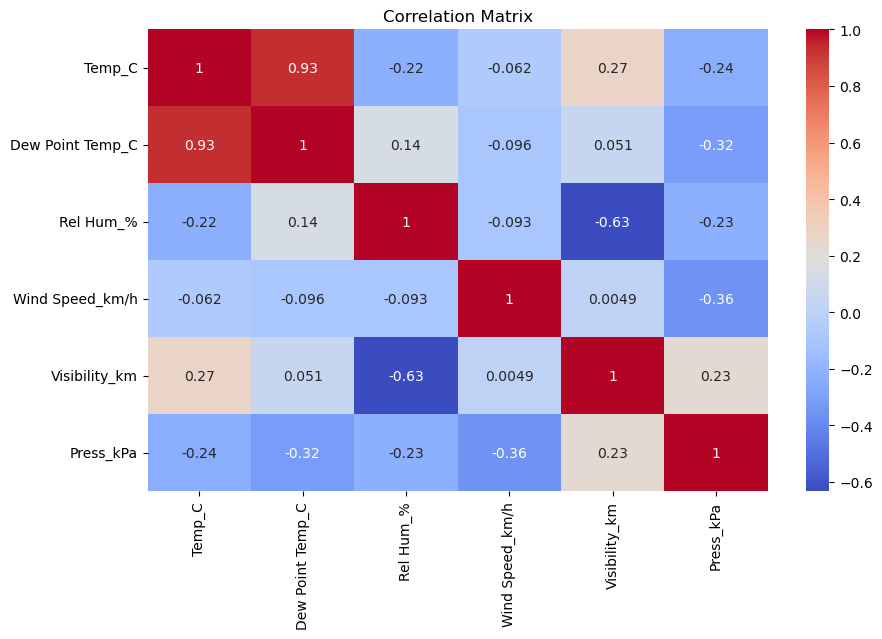

In [77]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [83]:
weather_counts = df['Weather_Grouped'].value_counts()
weather_percent = (weather_counts / len(df)) * 100 

df_weather = weather_percent.reset_index()
df_weather.columns = ['Weather_Grouped', 'Percentage']

fig = px.bar(
    df_weather,
    x='Weather_Grouped',
    y='Percentage',
    color='Weather_Grouped',
    text='Percentage',
    title='Percentage of Weather Conditions (out of 8784 observations)',
    height=500,
    category_orders={'Weather': df_weather.sort_values('Percentage', ascending=False)['Weather_Grouped'].tolist()}
)

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')

fig.show()


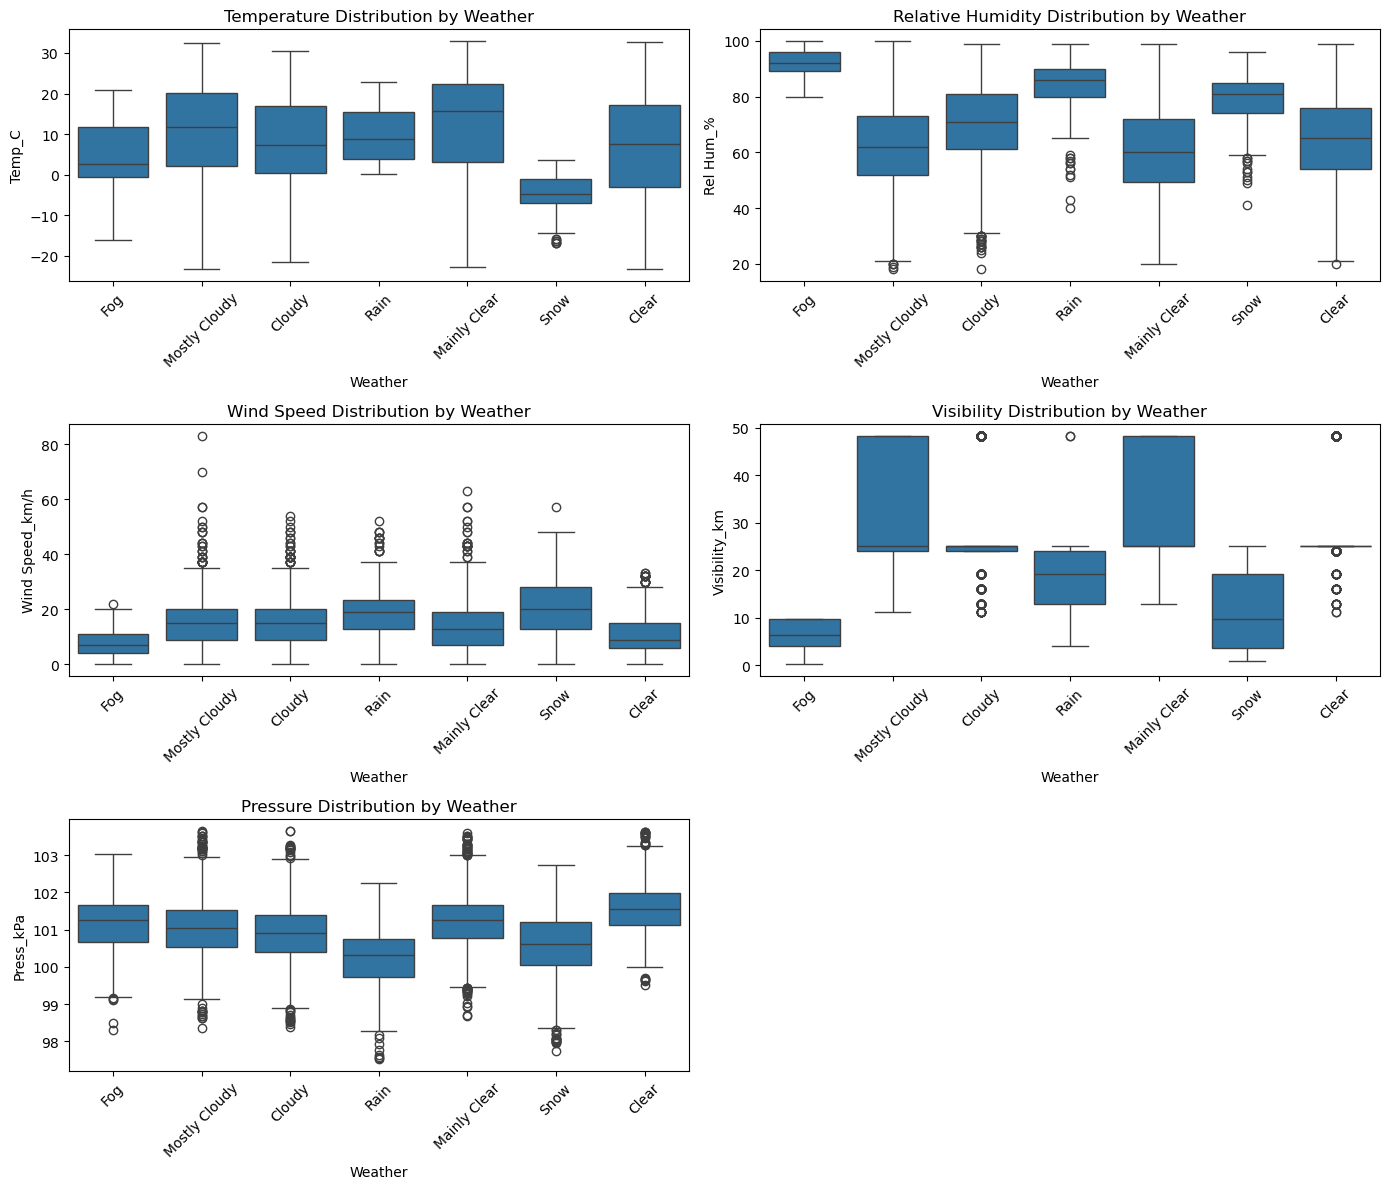

In [87]:
# Create a figure with 3 rows and 2 columns (6 slots, last one empty)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Flatten axes for easy indexing
axes = axes.flatten()

df_filtered = df[df['Weather'].isin(keep_categories)]

# Example plots (replace with your variables)
sns.boxplot(x='Weather', y='Temp_C', data=df_filtered, ax=axes[0])
axes[0].set_title('Temperature Distribution by Weather')

sns.boxplot(x='Weather', y='Rel Hum_%', data=df_filtered, ax=axes[1])
axes[1].set_title('Relative Humidity Distribution by Weather')

sns.boxplot(x='Weather', y='Wind Speed_km/h', data=df_filtered, ax=axes[2])
axes[2].set_title('Wind Speed Distribution by Weather')

sns.boxplot(x='Weather', y='Visibility_km', data=df_filtered, ax=axes[3])
axes[3].set_title('Visibility Distribution by Weather')

sns.boxplot(x='Weather', y='Press_kPa', data=df_filtered, ax=axes[4])
axes[4].set_title('Pressure Distribution by Weather')

# Hide the empty 6th subplot
fig.delaxes(axes[5])

# Rotate x-axis labels if needed
for ax in axes[:-1]:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [88]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['Month'] = df['Date/Time'].dt.month
df.head(10)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Grouped,Month
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog,Fog,1
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog,Fog,1
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog",Others,1
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog",Others,1
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog,Fog,1
5,2012-01-01 05:00:00,-1.4,-3.3,87,9,6.4,101.27,Fog,Fog,1
6,2012-01-01 06:00:00,-1.5,-3.1,89,7,6.4,101.29,Fog,Fog,1
7,2012-01-01 07:00:00,-1.4,-3.6,85,7,8.0,101.26,Fog,Fog,1
8,2012-01-01 08:00:00,-1.4,-3.6,85,9,8.0,101.23,Fog,Fog,1
9,2012-01-01 09:00:00,-1.3,-3.1,88,15,4.0,101.20,Fog,Fog,1


In [38]:
weather_month = df.groupby('Weather_Grouped')['Month'].value_counts().unstack().fillna(0)

# Convert to percentages per month
weather_month_percent = weather_month.div(weather_month.sum(axis=0), axis=1) * 100
weather_month_percent.round(2).astype(str) + '%'


Month,1,2,3,4,5,6,7,8,9,10,11,12
Weather_Grouped,,,,,,,,,,,,
Clear,10.35%,20.98%,20.83%,12.92%,14.65%,13.19%,17.34%,15.05%,18.06%,11.16%,19.58%,7.53%
Cloudy,19.49%,22.56%,21.37%,24.58%,18.28%,17.78%,14.92%,13.04%,16.94%,20.56%,18.19%,28.49%
Fog,2.42%,1.15%,4.7%,0.56%,2.15%,0.0%,0.13%,0.54%,0.28%,4.7%,1.25%,2.42%
Mainly Clear,15.73%,14.51%,18.41%,16.39%,25.4%,27.78%,40.05%,41.67%,32.36%,19.35%,22.5%,13.04%
Mostly Cloudy,22.04%,18.97%,16.53%,31.67%,25.67%,29.72%,23.52%,23.92%,22.08%,30.65%,25.83%,12.23%
Others,8.74%,5.75%,8.2%,5.56%,10.35%,4.17%,3.23%,4.57%,6.81%,9.27%,6.94%,22.85%
Rain,1.34%,3.02%,2.42%,7.64%,3.49%,7.36%,0.81%,1.21%,3.47%,4.3%,4.31%,2.69%
Snow,19.89%,13.07%,7.53%,0.69%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,1.39%,10.75%


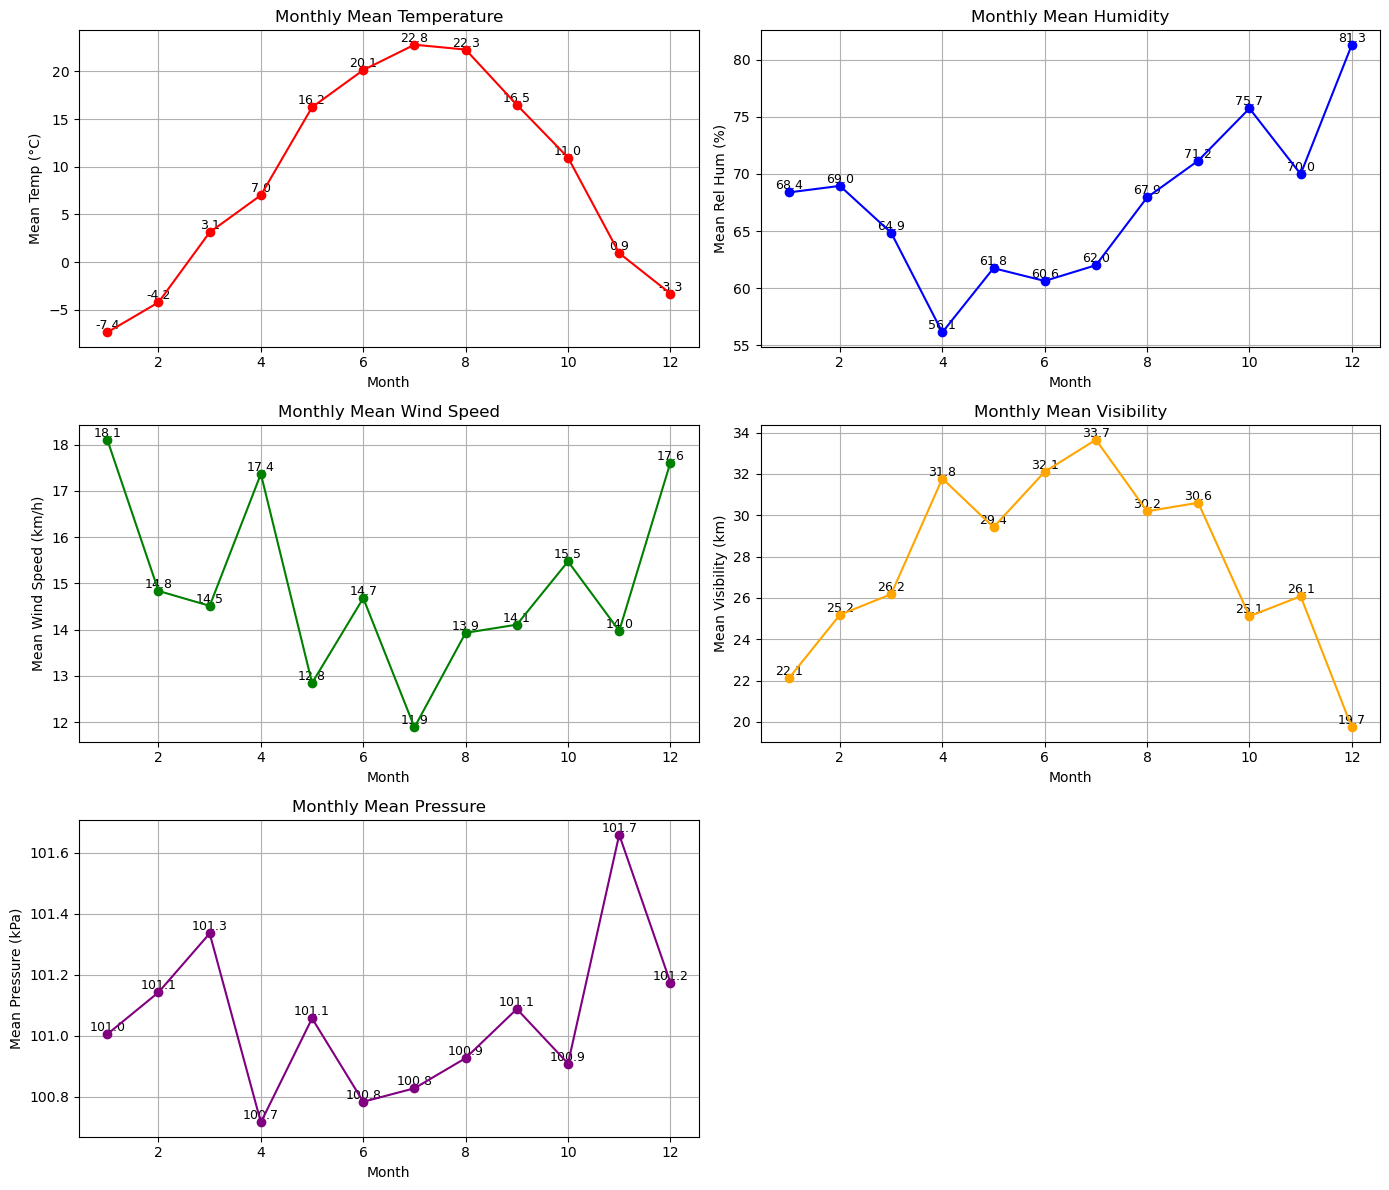

In [41]:
# Tworzymy figure z siatką 3x2
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()  # łatwiej indeksować


# Lista zmiennych i etykiet
variables = [
    ('Temp_C', 'Mean Temp (°C)', 'Monthly Mean Temperature', 'red'),
    ('Rel Hum_%', 'Mean Rel Hum (%)', 'Monthly Mean Humidity', 'blue'),
    ('Wind Speed_km/h', 'Mean Wind Speed (km/h)', 'Monthly Mean Wind Speed', 'green'),
    ('Visibility_km', 'Mean Visibility (km)', 'Monthly Mean Visibility', 'orange'),
    ('Press_kPa', 'Mean Pressure (kPa)', 'Monthly Mean Pressure', 'purple')
]

# Tworzymy wykresy
for i, (col, ylabel, title, color) in enumerate(variables):
    mean_vals = df.groupby('Month')[col].mean()
    axes[i].plot(mean_vals.index, mean_vals.values, color=color, marker='o', zorder=5)
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(ylabel)
    axes[i].set_title(title)
    axes[i].grid(True)

    # Dodaj wartości liczbowe nad punktami
    for month, value in mean_vals.items():
        axes[i].text(month, value, f'{value:.1f}', ha='center', va='bottom', fontsize=9)

# Usuwamy ostatni pusty subplot (bo mamy tylko 5 zmiennych)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [ ]:
df2.sample(10)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Month
5421,2012-08-13 21:00:00,22.4,17.8,75,6,25.0,100.87,Mainly Clear,8
898,2012-02-07 10:00:00,-6.2,-13.4,57,19,24.1,101.69,Mainly Clear,2
5857,2012-09-01 01:00:00,19.1,12.5,66,4,25.0,101.00,Mainly Clear,9
796,2012-02-03 04:00:00,-12.6,-15.1,82,7,16.1,102.42,Mainly Clear,2
3550,2012-05-27 22:00:00,17.5,9.1,58,0,25.0,101.33,Cloudy,5
116,2012-01-05 20:00:00,-9.8,-15.7,62,9,25.0,100.83,Clear,1
1114,2012-02-16 10:00:00,2.7,-1.1,76,11,24.1,101.83,Mainly Clear,2
6534,2012-09-29 06:00:00,10.2,8.8,91,11,25.0,101.27,Cloudy,9
1037,2012-02-13 05:00:00,-8.0,-15.0,57,22,25.0,100.33,Cloudy,2
2953,2012-05-03 01:00:00,11.4,8.9,85,15,25.0,101.17,Cloudy,5


In [91]:
df['Quarter'] = df['Date/Time'].dt.quarter

In [48]:
df_median = df.groupby('Quarter')[['Temp_C','Rel Hum_%','Wind Speed_km/h', 'Visibility_km', 'Press_kPa']].mean()
df_median_long = df_median.reset_index().melt(
    id_vars='Quarter',
    var_name='Variable',
    value_name='Mean'
)

In [58]:
fig = px.bar(
    df_median_long,
    x="Quarter",
    y="Mean",
    color="Variable",
    barmode="group",
    text=df_median_long['Mean'].round(1)  # wartości nad słupkami, zaokrąglone do 1 miejsca
)

# Ustawiamy pozycję tekstu nad słupkami
fig.update_traces(textposition='outside')

fig.show()

In [54]:
df_weather_counts = df.groupby(['Quarter', 'Weather_Grouped']).size().reset_index(name='Count')

# Obliczamy procent w ramach kwartału (transform zachowuje indeks)
df_weather_counts['Percent'] = df_weather_counts.groupby('Quarter')['Count'].transform(lambda x: x / x.sum() * 100)

# Tworzymy wykres słupkowy z procentami
fig = px.bar(
    df_weather_counts,
    x="Quarter",
    y="Percent",
    color="Weather_Grouped",
    barmode="group",
    title="Weather Types by Quarter (Percent)",
    text=df_weather_counts['Percent'].round(1).astype(str) + '%'
)

fig.update_traces(textposition='outside')  # wartości nad słupkami
fig.show()

In [59]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['Day'] = df['Date/Time'].dt.day_of_year
df.sample(10)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Grouped,Month,Quarter,Day
4069,2012-06-18 13:00:00,25.3,14.2,50,20,24.1,101.06,Mostly Cloudy,Mostly Cloudy,6,2,170
1569,2012-03-06 09:00:00,-11.3,-19.1,52,6,48.3,103.10,Clear,Clear,3,1,66
829,2012-02-04 13:00:00,-6.3,-12.7,60,13,48.3,102.11,Mainly Clear,Mainly Clear,2,1,35
7721,2012-11-17 17:00:00,0.9,-7.7,53,4,25.0,103.46,Clear,Clear,11,4,322
4549,2012-07-08 13:00:00,23.9,7.7,35,17,48.3,100.76,Mainly Clear,Mainly Clear,7,3,190
5092,2012-07-31 04:00:00,19.4,15.8,80,9,25.0,101.03,Mainly Clear,Mainly Clear,7,3,213
5318,2012-08-09 14:00:00,24.0,17.8,68,20,24.1,100.86,Rain Showers,Others,8,3,222
7469,2012-11-07 05:00:00,-4.3,-6.5,85,13,25.0,101.98,Clear,Clear,11,4,312
1922,2012-03-21 02:00:00,11.8,10.3,91,6,25.0,101.93,Clear,Clear,3,1,81
225,2012-01-10 09:00:00,1.6,-0.8,84,17,19.3,100.23,Cloudy,Cloudy,1,1,10


In [72]:
import plotly.express as px

# Liczba unikalnych typów pogody na każdy dzień
unique_weather_per_day = df.groupby('Day')['Weather'].nunique().reset_index(name='Unique_Weather')

# Histogram w Plotly
fig = px.histogram(
    unique_weather_per_day,
    x='Unique_Weather',
    nbins=unique_weather_per_day['Unique_Weather'].max(),
    title='Distribution of Unique Weather Types per Day',
    labels={'Unique_Weather': 'Number of Unique Weather Types per Day'},
    color_discrete_sequence=['skyblue'],
    text_auto=True
)

fig.update_layout(
    xaxis=dict(dtick=1),  # każda liczba na osi X
    yaxis_title='Number of Days'
)

fig.show()


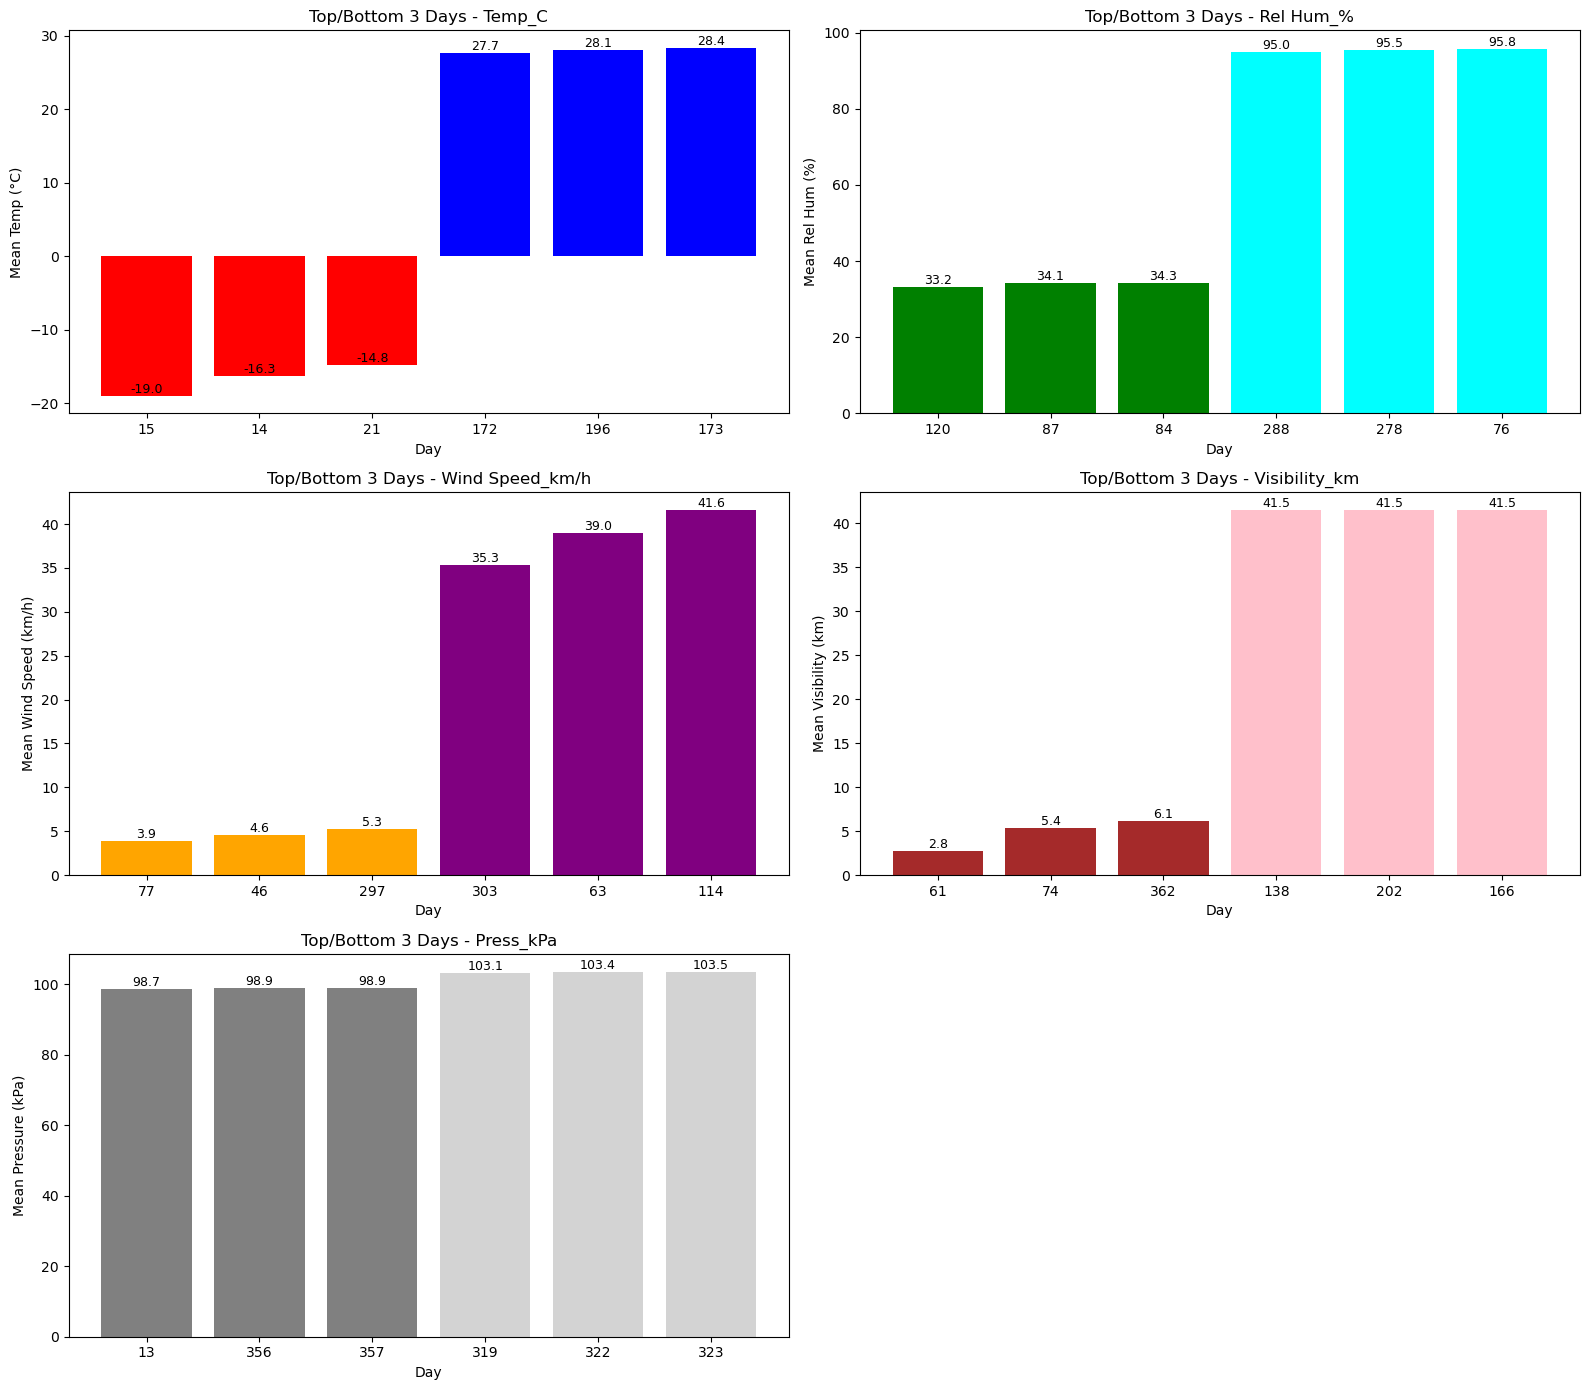

In [ ]:

# Lista zmiennych i kolorów
variables = [
    ('Temp_C', 'Mean Temp (°C)', 'red', 'blue'),
    ('Rel Hum_%', 'Mean Rel Hum (%)', 'green', 'cyan'),
    ('Wind Speed_km/h', 'Mean Wind Speed (km/h)', 'orange', 'purple'),
    ('Visibility_km', 'Mean Visibility (km)', 'brown', 'pink'),
    ('Press_kPa', 'Mean Pressure (kPa)', 'gray', 'lightgray')
]

# Tworzymy figure z siatką 3x2
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (col, ylabel, color_high, color_low) in enumerate(variables):
    day_mean = df.groupby('Day')[col].mean()
    top3_high = day_mean.nlargest(3)
    top3_low = day_mean.nsmallest(3)
    top_bottom = pd.concat([top3_high, top3_low]).sort_values()
    
    bars = axes[i].bar(
        top_bottom.index.astype(str),
        top_bottom.values,
        color=[color_high]*3 + [color_low]*3
    )
    
    axes[i].set_title(f'Top/Bottom 3 Days - {col}')
    axes[i].set_xlabel('Day')
    axes[i].set_ylabel(ylabel)
    
    # Dodaj wartości nad słupkami
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}',
                     ha='center', va='bottom', fontsize=9)

# Usuwamy ostatni pusty subplot, jeśli zmiennych jest 5
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


In [90]:
df.head(10)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Grouped,Month
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog,Fog,1
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog,Fog,1
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog",Others,1
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog",Others,1
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog,Fog,1
5,2012-01-01 05:00:00,-1.4,-3.3,87,9,6.4,101.27,Fog,Fog,1
6,2012-01-01 06:00:00,-1.5,-3.1,89,7,6.4,101.29,Fog,Fog,1
7,2012-01-01 07:00:00,-1.4,-3.6,85,7,8.0,101.26,Fog,Fog,1
8,2012-01-01 08:00:00,-1.4,-3.6,85,9,8.0,101.23,Fog,Fog,1
9,2012-01-01 09:00:00,-1.3,-3.1,88,15,4.0,101.20,Fog,Fog,1


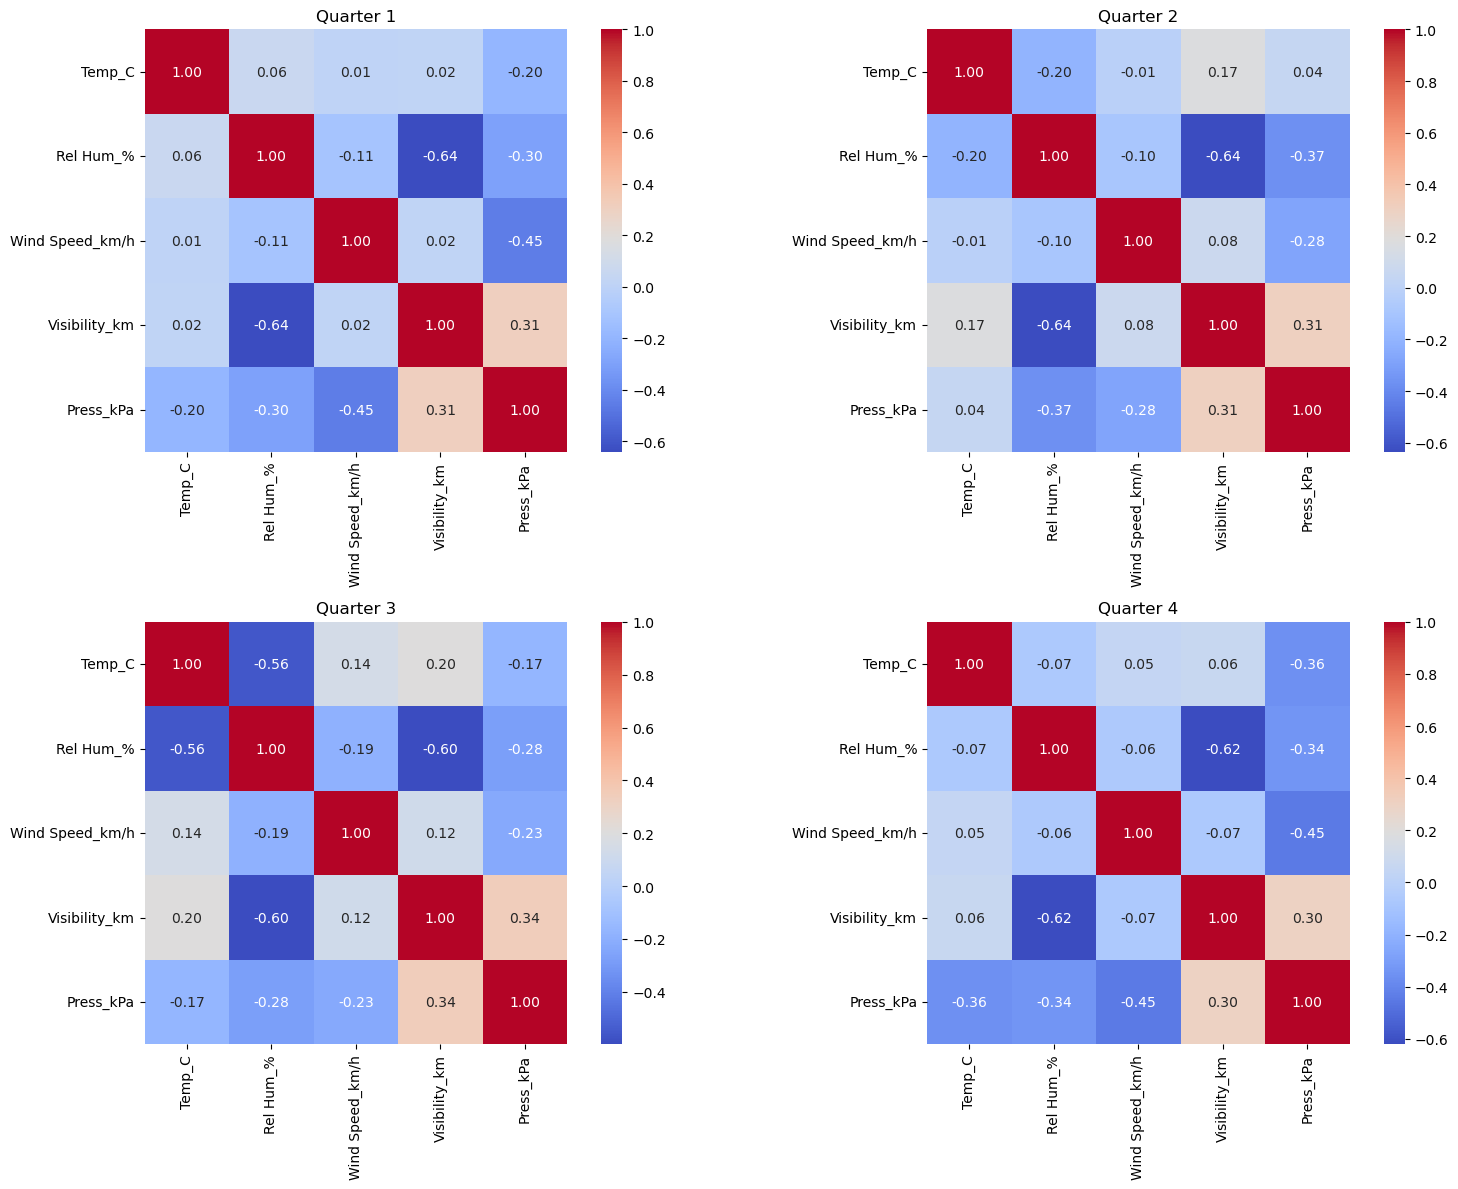

In [ ]:
# Wybieramy zmienne
cols = ['Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa']

# Unikalne kwartały (upewniamy się, że jest maks. 4)
quarters = sorted(df['Quarter'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # łatwiejsze indeksowanie

for i, q in enumerate(quarters):
    df_q = df[df['Quarter'] == q]
    corr_matrix = df_q[cols].corr()
    
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, ax=axes[i])
    axes[i].set_title(f'Quarter {q}')

plt.tight_layout()
plt.show()